# Breast Cancer Classification
## Final Group Model Comparison

### IT2011 – Artificial Intelligence and Machine Learning

This notebook presents the final group-level comparison of the six
individual machine-learning models developed by the group members.

Each member developed and evaluated a different model using the common
Breast Cancer Wisconsin (Original) dataset.

For a fair final comparison, all six models use the standardized final
modelling dataset containing **691 observations**, after removing **8 exact
duplicate observations** from the original 699 records.

A common stratified 80/20 split was used:

- Training observations: **552**
- Testing observations: **139**
- Training benign cases: **362**
- Training malignant cases: **190**
- Testing benign cases: **91**
- Testing malignant cases: **48**

Each member performed model-specific experimentation and hyperparameter
tuning using training data and cross-validation. The formally selected
optimum model from each member is compared here using the same held-out
test set.

### Individual Models

1. Member 01 – Decision Tree
2. Member 02 – K-Nearest Neighbors (KNN)
3. Member 03 – Random Forest
4. Member 04 – Logistic Regression
5. Member 05 – PCA + Logistic Regression
6. Member 06 – Support Vector Machine (SVM)

The main evaluation metrics are Accuracy, Precision, Recall, F1-score,
ROC-AUC, and False Negatives.

Because the positive class represents malignant cases, recall and false
negatives receive particular attention. A false negative represents a
malignant case incorrectly predicted as benign.

In [1]:
# ============================================================
# STEP 1 - IMPORT REQUIRED LIBRARIES
# ============================================================

# Pandas is used to create and manipulate comparison tables.
import pandas as pd

# NumPy is used for numerical operations.
import numpy as np

# Matplotlib is used to create comparison visualizations.
import matplotlib.pyplot as plt

# Path is used to create platform-independent output paths.
from pathlib import Path


# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

# Define the folder where group-level results will be saved.
output_dir = Path("results")

# Create the directory if it does not already exist.
output_dir.mkdir(
    parents=True,
    exist_ok=True
)


print("Libraries imported successfully.")
print("Output directory:", output_dir)

Libraries imported successfully.
Output directory: results


In [2]:
# ============================================================
# STEP 2 - CREATE FINAL SIX-MODEL COMPARISON TABLE
# ============================================================

# These are the formally selected optimum models from
# each member's individual final evaluation.
group_results = pd.DataFrame({

    # Group member responsible for the individual model.
    "Member": [
        "Member 01",
        "Member 02",
        "Member 03",
        "Member 04",
        "Member 05",
        "Member 06"
    ],

    # Individual machine-learning model.
    "Model": [
        "Decision Tree",
        "KNN",
        "Random Forest",
        "Logistic Regression",
        "PCA + Logistic Regression",
        "SVM"
    ],

    # All six selected models are tuned/optimized versions.
    "Version": [
        "Tuned",
        "Tuned",
        "Tuned",
        "Tuned",
        "Tuned",
        "Tuned"
    ],

    # Accuracy on the common 139-observation test set.
    "Accuracy": [
        0.9281,
        0.9640,
        0.9784,
        0.9712,
        0.9712,
        0.9712
    ],

    # Precision for the malignant class.
    "Precision": [
        0.9524,
        0.9778,
        0.9592,
        0.9583,
        0.9583,
        0.9583
    ],

    # Recall for the malignant class.
    "Recall": [
        0.8333,
        0.9167,
        0.9792,
        0.9583,
        0.9583,
        0.9583
    ],

    # F1-score for the malignant class.
    "F1": [
        0.8889,
        0.9462,
        0.9691,
        0.9583,
        0.9583,
        0.9583
    ],

    # ROC-AUC on the common held-out test set.
    "ROC-AUC": [
        0.9666,
        0.9823,
        0.9934,
        0.9961,
        0.9970,
        0.9970
    ],

    # False negatives:
    # malignant observations incorrectly predicted as benign.
    "False Negatives": [
        8,
        4,
        1,
        2,
        2,
        2
    ]
})


print("FINAL GROUP MODEL COMPARISON")
print("=" * 90)

group_results.round(4)

FINAL GROUP MODEL COMPARISON


,Member,Model,Version,Accuracy,Precision,Recall,F1,ROC-AUC,False Negatives
0,Member 01,Decision Tree,Tuned,0.9281,0.9524,0.8333,0.8889,0.9666,8
1,Member 02,KNN,Tuned,0.9640,0.9778,0.9167,0.9462,0.9823,4
2,Member 03,Random Forest,Tuned,0.9784,0.9592,0.9792,0.9691,0.9934,1
3,Member 04,Logistic Regression,Tuned,0.9712,0.9583,0.9583,0.9583,0.9961,2
4,Member 05,PCA + Logistic Regression,Tuned,0.9712,0.9583,0.9583,0.9583,0.9970,2
5,Member 06,SVM,Tuned,0.9712,0.9583,0.9583,0.9583,0.9970,2


In [3]:
# ============================================================
# STEP 3 - ADD COMMON TEST-SET INFORMATION
# ============================================================

# Every model was evaluated using the same number
# of held-out observations.
group_results["Test Observations"] = 139

# The common test set contains 48 malignant observations.
group_results["Actual Malignant"] = 48


# Calculate true positives from:
#
# Actual malignant = True Positives + False Negatives
group_results["True Positives"] = (
    group_results["Actual Malignant"]
    - group_results["False Negatives"]
)


print("COMMON TEST-SET VERIFICATION")
print("=" * 70)

group_results[
    [
        "Member",
        "Model",
        "Test Observations",
        "Actual Malignant",
        "True Positives",
        "False Negatives"
    ]
]

COMMON TEST-SET VERIFICATION


,Member,Model,Test Observations,Actual Malignant,True Positives,False Negatives
0,Member 01,Decision Tree,139,48,40,8
1,Member 02,KNN,139,48,44,4
2,Member 03,Random Forest,139,48,47,1
3,Member 04,Logistic Regression,139,48,46,2
4,Member 05,PCA + Logistic Regression,139,48,46,2
5,Member 06,SVM,139,48,46,2


In [4]:
# ============================================================
# STEP 4 - RANK MODELS BY HELD-OUT TEST F1-SCORE
# ============================================================

# F1 is useful because it balances precision and recall.
f1_ranking = (
    group_results[
        [
            "Member",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "False Negatives"
        ]
    ]
    .sort_values(
        by="F1",
        ascending=False
    )
    .reset_index(drop=True)
)


# Create a human-readable rank beginning at 1.
f1_ranking.insert(
    0,
    "Rank",
    range(
        1,
        len(f1_ranking) + 1
    )
)


print("MODEL RANKING BY F1-SCORE")
print("=" * 90)

f1_ranking.round(4)

MODEL RANKING BY F1-SCORE


,Rank,Member,Model,Accuracy,Precision,Recall,F1,ROC-AUC,False Negatives
0,1,Member 03,Random Forest,0.9784,0.9592,0.9792,0.9691,0.9934,1
1,2,Member 04,Logistic Regression,0.9712,0.9583,0.9583,0.9583,0.9961,2
2,3,Member 05,PCA + Logistic Regression,0.9712,0.9583,0.9583,0.9583,0.9970,2
3,4,Member 06,SVM,0.9712,0.9583,0.9583,0.9583,0.9970,2
4,5,Member 02,KNN,0.9640,0.9778,0.9167,0.9462,0.9823,4
5,6,Member 01,Decision Tree,0.9281,0.9524,0.8333,0.8889,0.9666,8


In [5]:
# ============================================================
# STEP 5 - RANK MODELS BY MALIGNANT-CLASS RECALL
# ============================================================

recall_ranking = (
    group_results[
        [
            "Member",
            "Model",
            "Recall",
            "False Negatives",
            "F1",
            "ROC-AUC"
        ]
    ]
    .sort_values(
        by=[
            "Recall",
            "False Negatives"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


recall_ranking.insert(
    0,
    "Rank",
    range(
        1,
        len(recall_ranking) + 1
    )
)


print("MODEL RANKING BY MALIGNANT-CLASS RECALL")
print("=" * 75)

recall_ranking.round(4)

MODEL RANKING BY MALIGNANT-CLASS RECALL


,Rank,Member,Model,Recall,False Negatives,F1,ROC-AUC
0,1,Member 03,Random Forest,0.9792,1,0.9691,0.9934
1,2,Member 04,Logistic Regression,0.9583,2,0.9583,0.9961
2,3,Member 05,PCA + Logistic Regression,0.9583,2,0.9583,0.9970
3,4,Member 06,SVM,0.9583,2,0.9583,0.9970
4,5,Member 02,KNN,0.9167,4,0.9462,0.9823
5,6,Member 01,Decision Tree,0.8333,8,0.8889,0.9666


In [6]:
# ============================================================
# STEP 6 - RANK MODELS BY ROC-AUC
# ============================================================

roc_ranking = (
    group_results[
        [
            "Member",
            "Model",
            "ROC-AUC",
            "F1",
            "Recall"
        ]
    ]
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)


roc_ranking.insert(
    0,
    "Rank",
    range(
        1,
        len(roc_ranking) + 1
    )
)


print("MODEL RANKING BY ROC-AUC")
print("=" * 70)

roc_ranking.round(4)

MODEL RANKING BY ROC-AUC


,Rank,Member,Model,ROC-AUC,F1,Recall
0,1,Member 05,PCA + Logistic Regression,0.9970,0.9583,0.9583
1,2,Member 06,SVM,0.9970,0.9583,0.9583
2,3,Member 04,Logistic Regression,0.9961,0.9583,0.9583
3,4,Member 03,Random Forest,0.9934,0.9691,0.9792
4,5,Member 02,KNN,0.9823,0.9462,0.9167
5,6,Member 01,Decision Tree,0.9666,0.8889,0.8333


## Performance Comparison

The selected models are compared using Accuracy, Precision, Recall,
F1-score, and ROC-AUC on the common held-out test set.

No single metric should be interpreted alone. Accuracy measures overall
correct classification, precision measures the reliability of positive
predictions, recall measures the ability to detect malignant cases,
F1-score balances precision and recall, and ROC-AUC measures the model's
ability to discriminate between the two classes across classification
thresholds.

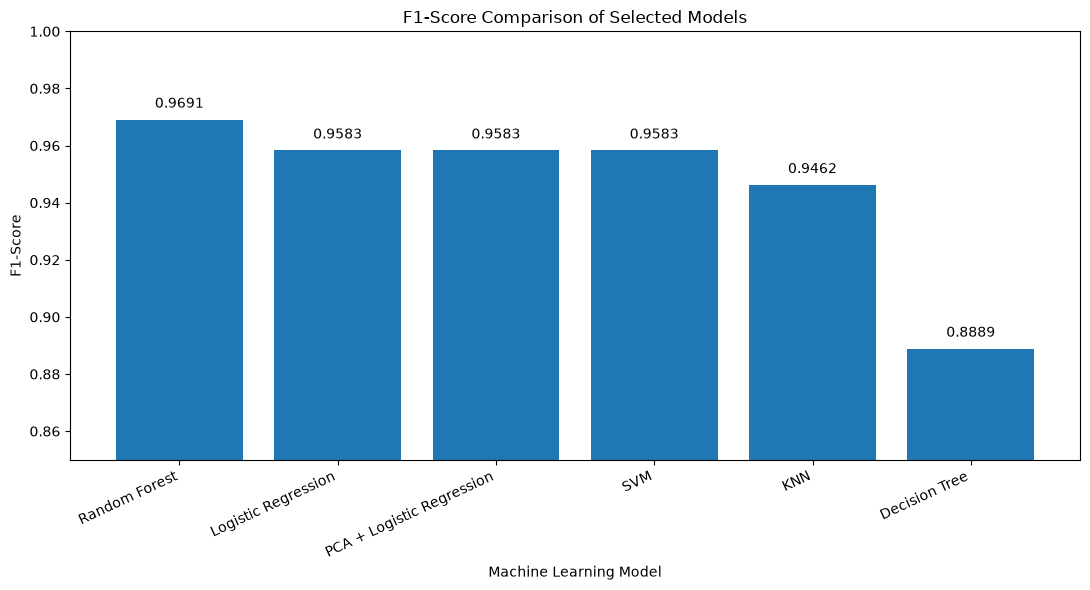

In [7]:
# ============================================================
# STEP 8 - COMPARE F1-SCORES
# ============================================================

# Sort models from highest to lowest F1-score.
f1_plot_data = (
    group_results
    .sort_values(
        by="F1",
        ascending=False
    )
)


# Create the F1 bar chart.
plt.figure(
    figsize=(11, 6)
)

bars = plt.bar(
    f1_plot_data["Model"],
    f1_plot_data["F1"]
)


# Add the exact F1-score above each bar.
for bar, value in zip(
    bars,
    f1_plot_data["F1"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.003,

        f"{value:.4f}",

        ha="center",
        va="bottom"
    )


plt.title(
    "F1-Score Comparison of Selected Models"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "F1-Score"
)


# Narrow the y-axis so the differences can be seen clearly.
plt.ylim(
    0.85,
    1.00
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


# Save the graph.
plt.savefig(
    output_dir / "f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

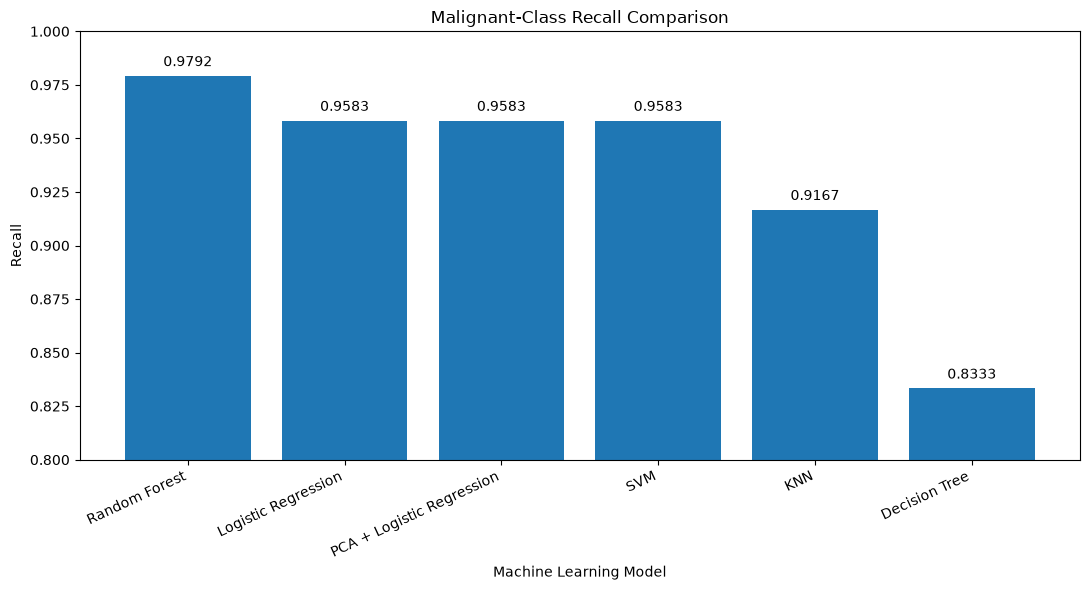

In [8]:
# ============================================================
# STEP 9 - COMPARE MALIGNANT-CLASS RECALL
# ============================================================

# Sort from highest to lowest recall.
recall_plot_data = (
    group_results
    .sort_values(
        by="Recall",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 6)
)


bars = plt.bar(
    recall_plot_data["Model"],
    recall_plot_data["Recall"]
)


# Display exact recall values.
for bar, value in zip(
    bars,
    recall_plot_data["Recall"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.003,

        f"{value:.4f}",

        ha="center",
        va="bottom"
    )


plt.title(
    "Malignant-Class Recall Comparison"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Recall"
)


plt.ylim(
    0.80,
    1.00
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


# Save for documentation.
plt.savefig(
    output_dir / "recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

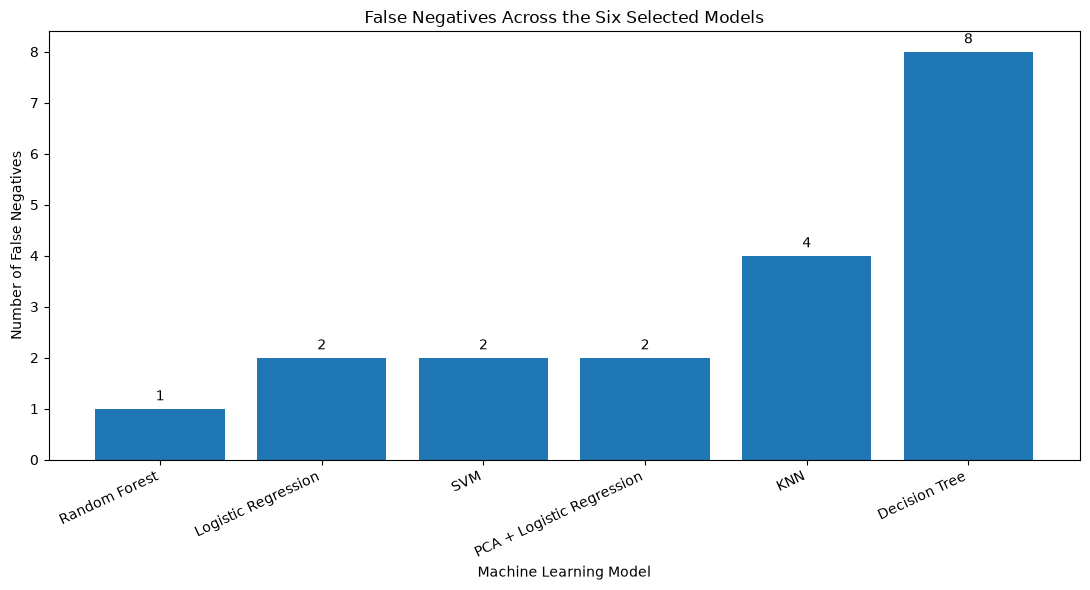

In [9]:
# ============================================================
# STEP 10 - COMPARE FALSE NEGATIVES
# ============================================================

# Sort from fewest missed malignant cases to most.
fn_plot_data = (
    group_results
    .sort_values(
        by="False Negatives",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 6)
)


bars = plt.bar(
    fn_plot_data["Model"],
    fn_plot_data["False Negatives"]
)


# Display the exact number of false negatives.
for bar, value in zip(
    bars,
    fn_plot_data["False Negatives"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.1,

        str(value),

        ha="center",
        va="bottom"
    )


plt.title(
    "False Negatives Across the Six Selected Models"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Number of False Negatives"
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


# Save for the final report.
plt.savefig(
    output_dir / "false_negative_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

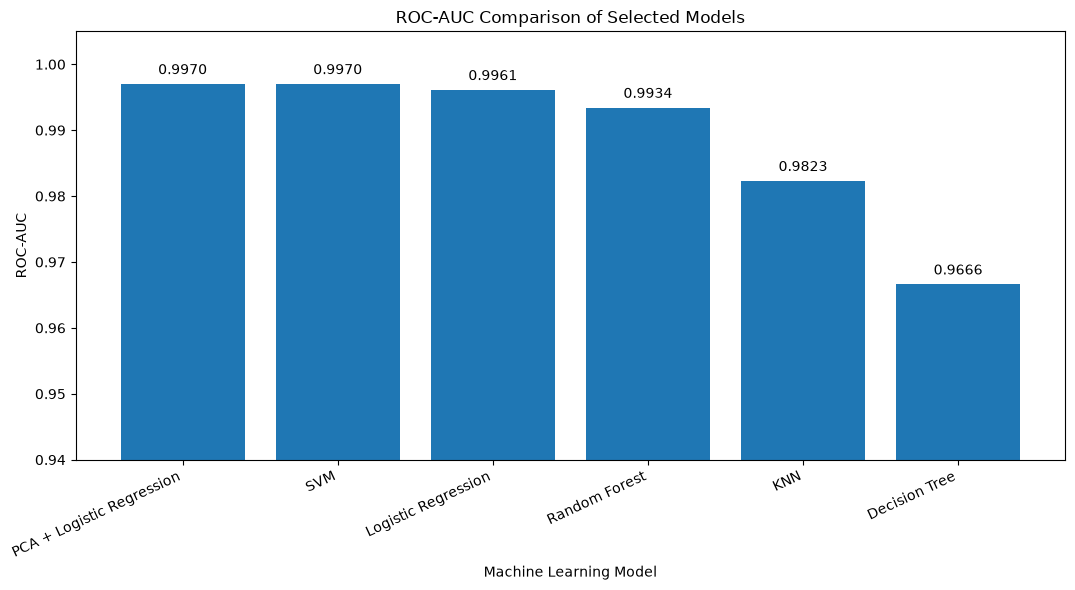

In [10]:
# ============================================================
# STEP 11 - COMPARE ROC-AUC
# ============================================================

# Sort models by ROC-AUC.
roc_plot_data = (
    group_results
    .sort_values(
        by="ROC-AUC",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 6)
)


bars = plt.bar(
    roc_plot_data["Model"],
    roc_plot_data["ROC-AUC"]
)


# Display exact ROC-AUC values.
for bar, value in zip(
    bars,
    roc_plot_data["ROC-AUC"]
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.001,

        f"{value:.4f}",

        ha="center",
        va="bottom"
    )


plt.title(
    "ROC-AUC Comparison of Selected Models"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "ROC-AUC"
)


plt.ylim(
    0.94,
    1.005
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.tight_layout()


# Save the figure.
plt.savefig(
    output_dir / "roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [11]:
# ============================================================
# STEP 12 - MODEL CHARACTERISTICS AND OBSERVED BEHAVIOR
# ============================================================

model_characteristics = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "KNN",
        "Random Forest",
        "Logistic Regression",
        "PCA + Logistic Regression",
        "SVM"
    ],

    "Main Strength": [
        "Simple and interpretable tree structure",
        "Simple distance-based classification",
        "Strong nonlinear ensemble performance",
        "Simple and interpretable probabilistic model",
        "Dimensionality reduction with strong discrimination",
        "Strong classification boundary and discrimination"
    ],

    "Main Limitation": [
        "Can overfit and can be unstable",
        "Sensitive to scaling and choice of neighbors",
        "Less interpretable than a single tree",
        "Assumes a mainly linear decision relationship",
        "Principal components reduce direct feature interpretability",
        "Less directly interpretable than linear models"
    ],

    "Observed Final Behavior": [
        "Lowest recall and highest false negatives",
        "Highest precision but lower recall than top models",
        "Highest F1 and recall with only one false negative",
        "Strong balanced precision and recall",
        "Strong balanced performance and highest ROC-AUC",
        "Strong balanced performance and highest ROC-AUC"
    ]
})


model_characteristics

,Model,Main Strength,Main Limitation,Observed Final Behavior
0,Decision Tree,Simple and interpretable tree structure,Can overfit and can be unstable,Lowest recall and highest false negatives
1,KNN,Simple distance-based classification,Sensitive to scaling and choice of neighbors,Highest precision but lower recall than top mo...
2,Random Forest,Strong nonlinear ensemble performance,Less interpretable than a single tree,Highest F1 and recall with only one false nega...
3,Logistic Regression,Simple and interpretable probabilistic model,Assumes a mainly linear decision relationship,Strong balanced precision and recall
4,PCA + Logistic Regression,Dimensionality reduction with strong discrimin...,Principal components reduce direct feature int...,Strong balanced performance and highest ROC-AUC
5,SVM,Strong classification boundary and discrimination,Less directly interpretable than linear models,Strong balanced performance and highest ROC-AUC


## Final Group Model Selection

The six selected models showed generally strong classification performance,
but their strengths differed across evaluation metrics.

The **Random Forest** achieved the highest held-out test accuracy
(**0.9784**), recall (**0.9792**), and F1-score (**0.9691**). It correctly
identified **47 of the 48 malignant test observations**, resulting in only
**1 false negative**.

The **PCA + Logistic Regression** and **SVM** models achieved the highest
ROC-AUC values (**0.9970**), while standard Logistic Regression achieved a
similarly high ROC-AUC of **0.9961**. This indicates excellent class
discrimination by these models.

KNN achieved the highest precision (**0.9778**) but had lower malignant
recall (**0.9167**) and produced four false negatives.

The tuned Decision Tree provided useful interpretability but produced the
lowest recall (**0.8333**) and the largest number of false negatives
(**8**) among the selected models.

Considering the combination of held-out F1-score, malignant-class recall,
accuracy, and false-negative count, **Random Forest is selected as the
strongest overall experimental model in the final group comparison**.

However, no model was best according to every metric. In particular,
PCA + Logistic Regression and SVM achieved higher ROC-AUC values than
Random Forest. Therefore, the final selection reflects the group's
priority on correctly detecting malignant cases while maintaining strong
overall classification performance.

These findings are based on a relatively small historical dataset and a
single held-out test split. They do not establish clinical readiness.
External validation on larger, more diverse and contemporary datasets
would be required before considering real-world medical use.

In [12]:
# ============================================================
# STEP 13 - SAVE FINAL GROUP COMPARISON TABLES
# ============================================================

# ------------------------------------------------------------
# 1. Save the complete six-model comparison
# ------------------------------------------------------------

group_results.to_csv(
    output_dir / "final_six_model_comparison.csv",
    index=False
)


# ------------------------------------------------------------
# 2. Save the F1-score ranking
# ------------------------------------------------------------

f1_ranking.to_csv(
    output_dir / "f1_ranking.csv",
    index=False
)


# ------------------------------------------------------------
# 3. Save the recall ranking
# ------------------------------------------------------------

recall_ranking.to_csv(
    output_dir / "recall_ranking.csv",
    index=False
)


# ------------------------------------------------------------
# 4. Save the ROC-AUC ranking
# ------------------------------------------------------------

roc_ranking.to_csv(
    output_dir / "roc_auc_ranking.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Save model characteristics and observed behavior
# ------------------------------------------------------------

model_characteristics.to_csv(
    output_dir / "model_characteristics.csv",
    index=False
)


print("Final group comparison tables saved successfully.")
print("Output folder:", output_dir)

Final group comparison tables saved successfully.
Output folder: results


In [13]:
# ============================================================
# STEP 14 - CREATE REPORT-READY FINAL SUMMARY
# ============================================================

# Create a concise table containing the most important
# information needed for the final report and viva.
final_summary = group_results[
    [
        "Member",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "False Negatives"
    ]
].copy()


# Add a short final interpretation for each selected model.
final_summary["Key Interpretation"] = [

    # Member 01
    "Interpretable, but lowest recall and highest false negatives",

    # Member 02
    "Highest precision, but missed four malignant cases",

    # Member 03
    "Highest accuracy, recall and F1; only one false negative",

    # Member 04
    "Strong balanced performance with high ROC-AUC",

    # Member 05
    "Strong balanced performance and joint-highest ROC-AUC",

    # Member 06
    "Strong balanced performance and joint-highest ROC-AUC"
]


# Save the report-ready summary.
final_summary.to_csv(
    output_dir / "final_report_summary.csv",
    index=False
)


print(
    "FINAL REPORT SUMMARY"
)

print(
    "=" * 100
)

final_summary.round(4)

FINAL REPORT SUMMARY


,Member,Model,Accuracy,Precision,Recall,F1,ROC-AUC,False Negatives,Key Interpretation
0,Member 01,Decision Tree,0.9281,0.9524,0.8333,0.8889,0.9666,8,"Interpretable, but lowest recall and highest f..."
1,Member 02,KNN,0.9640,0.9778,0.9167,0.9462,0.9823,4,"Highest precision, but missed four malignant c..."
2,Member 03,Random Forest,0.9784,0.9592,0.9792,0.9691,0.9934,1,"Highest accuracy, recall and F1; only one fals..."
3,Member 04,Logistic Regression,0.9712,0.9583,0.9583,0.9583,0.9961,2,Strong balanced performance with high ROC-AUC
4,Member 05,PCA + Logistic Regression,0.9712,0.9583,0.9583,0.9583,0.9970,2,Strong balanced performance and joint-highest ...
5,Member 06,SVM,0.9712,0.9583,0.9583,0.9583,0.9970,2,Strong balanced performance and joint-highest ...


In [14]:
# ============================================================
# STEP 15 - SAVE FINAL SELECTED GROUP MODEL
# ============================================================

# Random Forest is selected based on the combination of:
#
# - highest held-out accuracy,
# - highest malignant recall,
# - highest F1-score,
# - and lowest false-negative count.
final_selected_model = (
    group_results[
        group_results["Model"]
        == "Random Forest"
    ]
    .copy()
)


# Add the reason for the group-level selection.
final_selected_model["Selection Reason"] = (
    "Highest test accuracy, recall and F1-score, "
    "with only one false negative."
)


# Save the final selection.
final_selected_model.to_csv(
    output_dir / "final_selected_model.csv",
    index=False
)


print(
    "FINAL SELECTED GROUP MODEL"
)

print(
    "=" * 80
)

final_selected_model

FINAL SELECTED GROUP MODEL


,Member,Model,Version,Accuracy,Precision,Recall,F1,ROC-AUC,False Negatives,Test Observations,Actual Malignant,True Positives,Selection Reason
2,Member 03,Random Forest,Tuned,0.9784,0.9592,0.9792,0.9691,0.9934,1,139,48,47,"Highest test accuracy, recall and F1-score, wi..."


In [15]:
# ============================================================
# STEP 16 - FINAL GROUP COMPARISON CONSISTENCY CHECK
# ============================================================

print(
    "FINAL GROUP COMPARISON CHECK"
)

print(
    "=" * 70
)


# Confirm exactly six individual optimum models exist.
print(
    "Number of selected models:",
    len(group_results)
)


# Confirm all models used the common test-set size.
print(
    "Common test-set sizes:",
    sorted(
        group_results[
            "Test Observations"
        ].unique()
    )
)


# Confirm the number of actual malignant test cases.
print(
    "Actual malignant cases:",
    sorted(
        group_results[
            "Actual Malignant"
        ].unique()
    )
)


# Identify the model with the highest F1-score.
best_f1_model = (
    group_results
    .loc[
        group_results["F1"].idxmax(),
        "Model"
    ]
)


# Identify the model with the highest recall.
best_recall_model = (
    group_results
    .loc[
        group_results["Recall"].idxmax(),
        "Model"
    ]
)


# Identify the minimum number of false negatives.
minimum_fn = (
    group_results[
        "False Negatives"
    ].min()
)


print(
    "\nHighest F1 model:",
    best_f1_model
)

print(
    "Highest recall model:",
    best_recall_model
)

print(
    "Minimum false negatives:",
    minimum_fn
)


print(
    "\nGroup comparison completed successfully."
)

FINAL GROUP COMPARISON CHECK
Number of selected models: 6
Common test-set sizes: [np.int64(139)]
Actual malignant cases: [np.int64(48)]

Highest F1 model: Random Forest
Highest recall model: Random Forest
Minimum false negatives: 1

Group comparison completed successfully.
